# Week 5 — Combining Models: CART, Boosting and Ensembles
**Course:** 21CSC305P Machine Learning · **Unit 5 – Combining models**

**Topics covered:** Bayesian model averaging · boosting · adaptive basis function models · CART · generalised additive models · ensemble learning.

**Practice tasks**
1. Implement CART learning algorithms to perform categorisation
2. Implement ensemble learning models to perform classification

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from math import comb
from scipy.special import logsumexp

from sklearn.datasets import load_iris, load_wine, load_digits, load_breast_cancer, load_diabetes, make_moons, make_classification
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, StratifiedKFold, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, SplineTransformer
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier,
                              HistGradientBoostingClassifier, VotingClassifier, StackingClassifier, GradientBoostingRegressor)
from sklearn.linear_model import LogisticRegression, Ridge, LinearRegression
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, adjusted_rand_score, r2_score
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, fcluster

np.random.seed(0)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
PAL = sns.color_palette("tab10")

def boundary(ax, model, X, y, title="", pad=.5, cmap="RdBu_r"):
    g0, g1 = np.meshgrid(np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, 250), np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, 250))
    Z = model.predict(np.c_[g0.ravel(), g1.ravel()]).reshape(g0.shape)
    ax.contourf(g0, g1, Z, alpha=.35, cmap=cmap, levels=np.arange(Z.min() - .5, Z.max() + 1.5)); ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, edgecolor="k", s=18); ax.set_title(title)

## Part A — Theory in code

### A1. Bayesian model averaging (BMA) vs. combining models
BMA treats *which model generated the data* as a latent variable: $p(\mathbf t^*|\mathbf x^*,\mathcal D)=\sum_m p(\mathbf t^*|\mathbf x^*,\mathcal M_m,\mathcal D)\,p(\mathcal M_m|\mathcal D)$
with $p(\mathcal M_m|\mathcal D)\propto p(\mathcal D|\mathcal M_m)p(\mathcal M_m)$ (the **evidence**). As data accumulate the weights concentrate on one model — BMA is *model selection under uncertainty*,
not the same as a committee/ensemble that averages models that are all (partly) right.

Below, polynomials of degree 0–9 are compared via the closed-form evidence of Bayesian linear regression. The data truly come from a cubic.

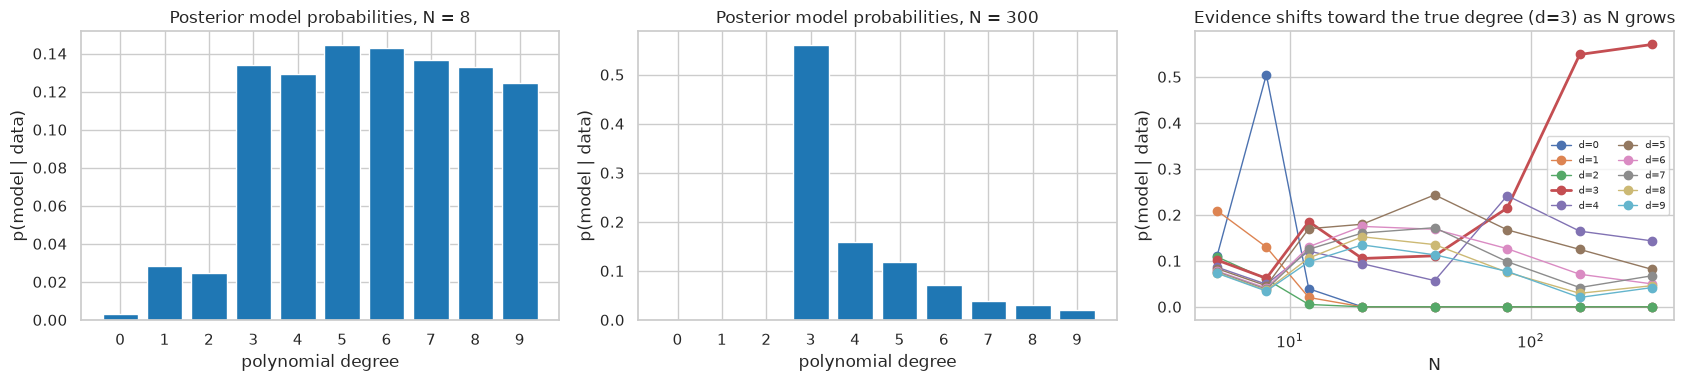

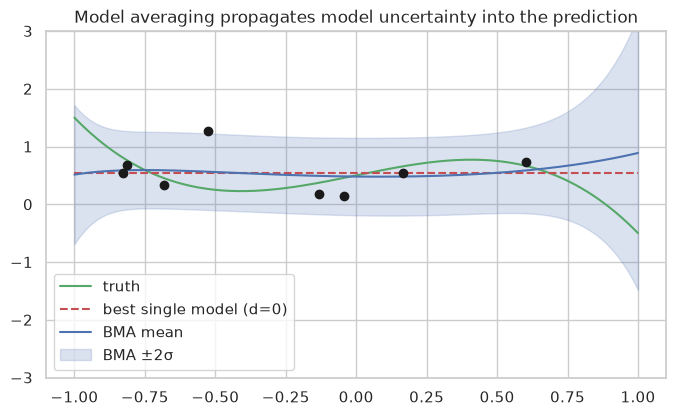

In [2]:
def poly_design(x, d): return np.vander(x, d + 1, increasing=True)

def bayes_fit(x, t, d, alpha=1.0, beta=1 / 0.3 ** 2):
    Phi = poly_design(x, d); N, M = Phi.shape
    A = alpha * np.eye(M) + beta * Phi.T @ Phi; mN = beta * np.linalg.solve(A, Phi.T @ t)
    E = beta / 2 * np.sum((t - Phi @ mN) ** 2) + alpha / 2 * mN @ mN
    log_ev = M / 2 * np.log(alpha) + N / 2 * np.log(beta) - E - 0.5 * np.linalg.slogdet(A)[1] - N / 2 * np.log(2 * np.pi)
    return mN, np.linalg.inv(A), log_ev

f_true = lambda x: 0.5 + x - 2 * x ** 3
def weights_for(N, seed=0, degrees=range(0, 10)):
    r = np.random.default_rng(seed); x = r.uniform(-1, 1, N); t = f_true(x) + r.normal(0, 0.3, N)
    fits = [bayes_fit(x, t, d) for d in degrees]; le = np.array([f[2] for f in fits]); return x, t, fits, np.exp(le - logsumexp(le))

fig, ax = plt.subplots(1, 3, figsize=(17, 4))
for a_, N in zip(ax[:2], [8, 300]):
    x, t, fits, w = weights_for(N); a_.bar(range(10), w, color=PAL[0]); a_.set(xlabel="polynomial degree", ylabel="p(model | data)", title=f"Posterior model probabilities, N = {N}", xticks=range(10))
Ns = [5, 8, 12, 20, 40, 80, 160, 320]; W = np.array([weights_for(N, seed=1)[3] for N in Ns])
for d in range(10): ax[2].plot(Ns, W[:, d], "o-", label=f"d={d}", lw=2 if d == 3 else 1)
ax[2].set_xscale("log"); ax[2].set(xlabel="N", ylabel="p(model | data)", title="Evidence shifts toward the true degree (d=3) as N grows"); ax[2].legend(ncol=2, fontsize=7)
plt.tight_layout(); plt.show()

# BMA predictive vs best single model (small data)
x, t, fits, w = weights_for(8, seed=3); xg = np.linspace(-1, 1, 200)
means = np.array([poly_design(xg, d) @ f[0] for d, f in enumerate(fits)]); bma = w @ means
vars_ = np.array([1 / (1 / 0.3 ** 2) + np.einsum("ij,jk,ik->i", poly_design(xg, d), f[1], poly_design(xg, d)) for d, f in enumerate(fits)])
bma_var = w @ (vars_ + means ** 2) - bma ** 2
plt.figure(figsize=(8, 4.5)); plt.plot(xg, f_true(xg), "g", label="truth")
plt.plot(xg, means[int(np.argmax(w))], "r--", label=f"best single model (d={int(np.argmax(w))})"); plt.plot(xg, bma, "b", label="BMA mean"); plt.fill_between(xg, bma - 2 * np.sqrt(bma_var), bma + 2 * np.sqrt(bma_var), alpha=.2, color="b", label="BMA ±2σ")
plt.scatter(x, t, c="k", zorder=5); plt.ylim(-3, 3); plt.legend(); plt.title("Model averaging propagates model uncertainty into the prediction"); plt.show()

### A2. Committees: why averaging helps (bagging)
If $M$ models have errors with variance $\sigma^2$ and average pairwise correlation $\rho$, the averaged error variance is $\rho\sigma^2+\frac{1-\rho}{M}\sigma^2$ — averaging
removes the *independent* part of the error. **Bagging** trains each model on a bootstrap resample to create (partly) decorrelated models; high-variance learners such as deep trees benefit most.

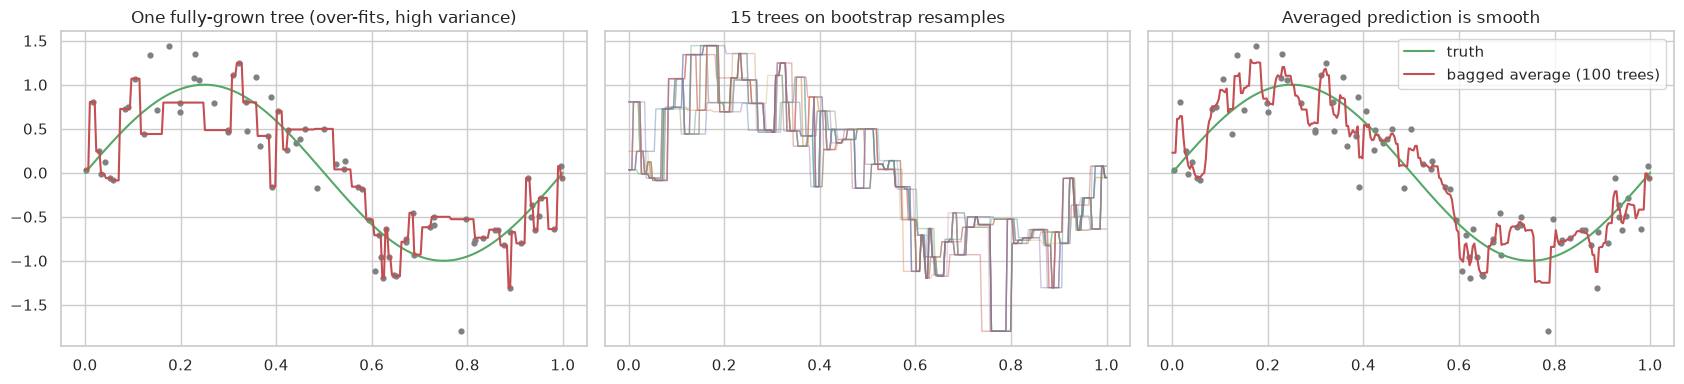

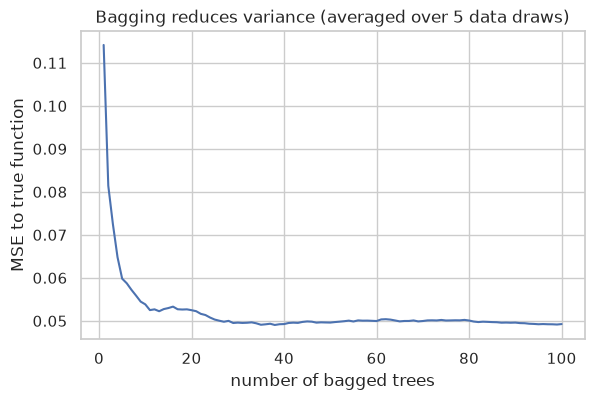

In [3]:
rng = np.random.default_rng(0)
x = np.sort(rng.uniform(0, 1, 80)); t = np.sin(2 * np.pi * x) + rng.normal(0, 0.35, 80); xg = np.linspace(0, 1, 300)[:, None]

def bagged_trees(x, t, B, depth=None, seed=0):
    r = np.random.default_rng(seed); preds = []
    for _ in range(B):
        i = r.integers(0, len(x), len(x)); preds.append(DecisionTreeRegressor(max_depth=depth).fit(x[i, None], t[i]).predict(xg))
    return np.array(preds)

P = bagged_trees(x, t, 100)
fig, ax = plt.subplots(1, 3, figsize=(17, 4), sharey=True)
ax[0].plot(xg, np.sin(2 * np.pi * xg), "g"); ax[0].plot(xg, P[0], "r"); ax[0].scatter(x, t, s=12, c="gray"); ax[0].set_title("One fully-grown tree (over-fits, high variance)")
for p in P[:15]: ax[1].plot(xg, p, alpha=.4, lw=1)
ax[1].set_title("15 trees on bootstrap resamples")
ax[2].plot(xg, np.sin(2 * np.pi * xg), "g", label="truth"); ax[2].plot(xg, P.mean(0), "r", label="bagged average (100 trees)"); ax[2].scatter(x, t, s=12, c="gray"); ax[2].legend(); ax[2].set_title("Averaged prediction is smooth")
plt.tight_layout(); plt.show()

# error vs number of trees (test MSE, averaged over data draws)
xt = xg[:, 0]; truth = np.sin(2 * np.pi * xt)
curves = []
for rep in range(5):
    r = np.random.default_rng(rep + 10); xr = r.uniform(0, 1, 80); tr = np.sin(2 * np.pi * xr) + r.normal(0, 0.35, 80)
    Pr = np.array([DecisionTreeRegressor().fit(xr[i, None], tr[i]).predict(xg) for i in [r.integers(0, 80, 80) for _ in range(100)]])
    curves.append([np.mean((Pr[:b].mean(0) - truth) ** 2) for b in range(1, 101)])
plt.figure(figsize=(6.5, 4)); plt.plot(range(1, 101), np.mean(curves, 0)); plt.xlabel("number of bagged trees"); plt.ylabel("MSE to true function"); plt.title("Bagging reduces variance (averaged over 5 data draws)"); plt.show()

### A3. Boosting and adaptive basis function models
An *adaptive basis function model* learns the basis functions: $f(\mathbf x)=w_0+\sum_{m=1}^M w_m\phi_m(\mathbf x;\boldsymbol\gamma_m)$.
**Boosting** fits it greedily by forward stagewise additive modelling, adding one weak learner at a time to correct what the ensemble still gets wrong.

* **AdaBoost** (exponential loss): re-weight examples $w_n\leftarrow w_n\exp(-\alpha_m t_n h_m(\mathbf x_n))$ with $\alpha_m=\tfrac12\ln\frac{1-\epsilon_m}{\epsilon_m}$; final classifier $\mathrm{sign}\sum\alpha_mh_m$.
* **Gradient boosting** (any differentiable loss): fit each new tree to the negative gradient (residuals for squared loss) and add it with a shrinkage factor.

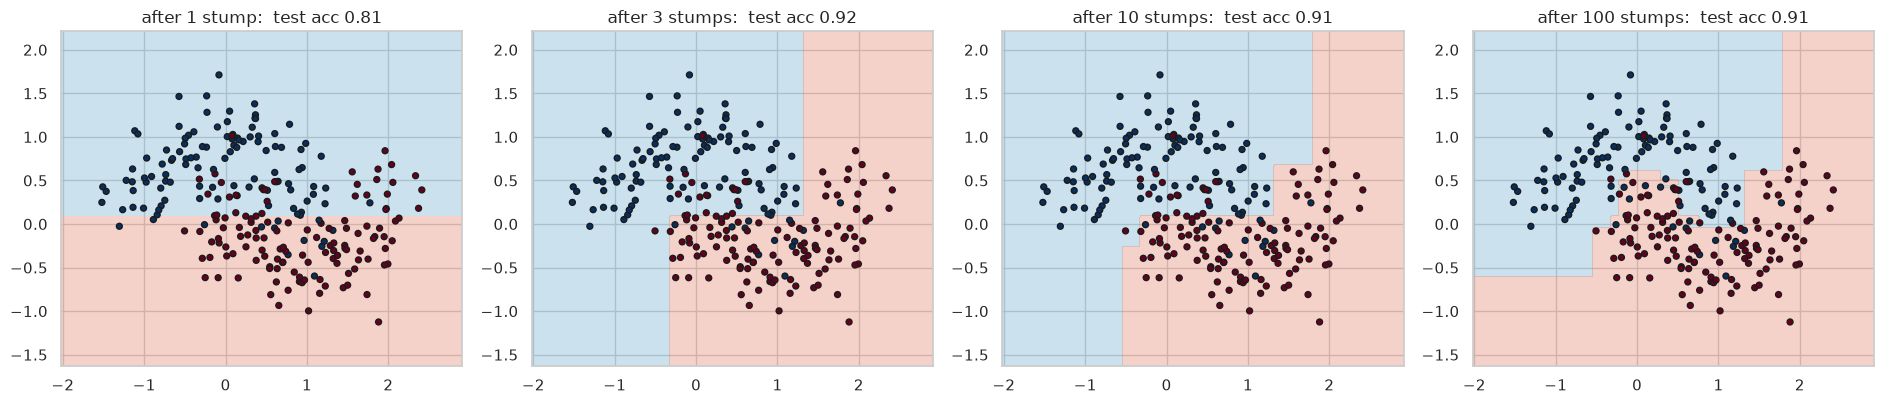

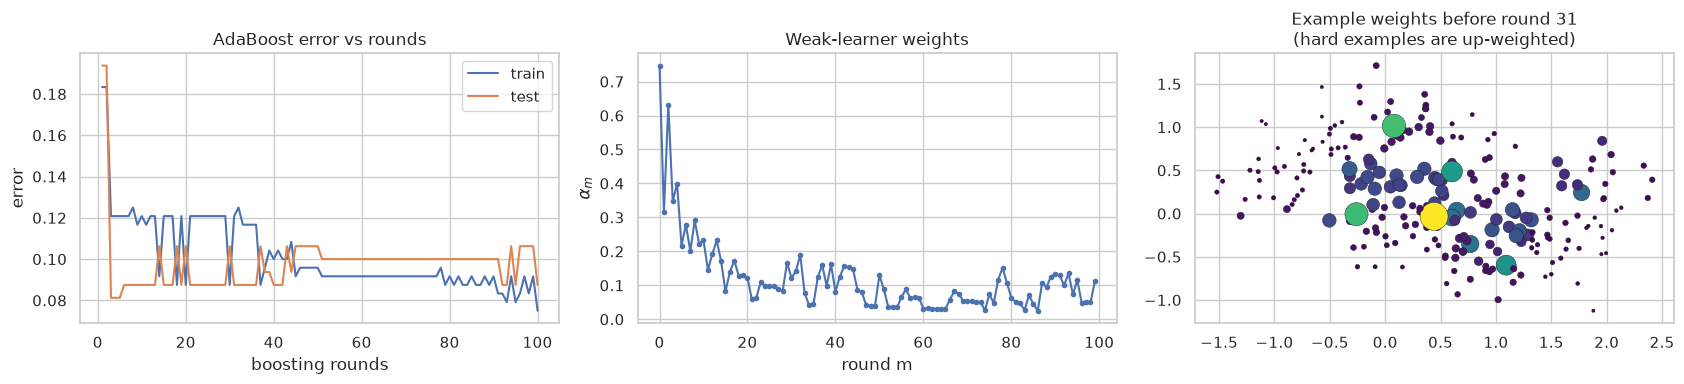

test accuracy: ours 0.912   sklearn AdaBoost 0.912   single stump 0.806


In [4]:
class MyAdaBoost:
    """Discrete AdaBoost with decision stumps (labels in {-1,+1})."""
    def __init__(self, n_rounds=50): self.M = n_rounds
    def fit(self, X, y):
        N = len(X); w = np.full(N, 1 / N); self.stumps, self.alphas, self.w_hist = [], [], []
        for _ in range(self.M):
            h = DecisionTreeClassifier(max_depth=1).fit(X, y, sample_weight=w); pred = h.predict(X)
            err = np.clip(w[pred != y].sum() / w.sum(), 1e-12, 1 - 1e-12); a = 0.5 * np.log((1 - err) / err)
            self.w_hist.append(w.copy()); w = w * np.exp(-a * y * pred); w /= w.sum()
            self.stumps.append(h); self.alphas.append(a)
        return self
    def decision_function(self, X, m=None):
        m = m or self.M; return sum(a * h.predict(X) for a, h in zip(self.alphas[:m], self.stumps[:m]))
    def predict(self, X, m=None): return np.sign(self.decision_function(X, m))

Xa, ya = make_moons(400, noise=0.3, random_state=0); ya = 2 * ya - 1
Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(Xa, ya, test_size=0.4, random_state=0)
ada = MyAdaBoost(100).fit(Xa_tr, ya_tr)

class Staged:                                        # wrapper to draw the boundary after m rounds
    def __init__(self, m, ens): self.m, self.ens = m, ens
    def predict(self, X): return (self.ens.predict(X, self.m) > 0).astype(int)
fig, ax = plt.subplots(1, 4, figsize=(19, 4.2))
for a_, m in zip(ax, [1, 3, 10, 100]):
    boundary(a_, Staged(m, ada), Xa_tr, (ya_tr > 0).astype(int), f"after {m} stump{'s' if m > 1 else ''}:  test acc {np.mean(ada.predict(Xa_te, m) == ya_te):.2f}")
plt.tight_layout(); plt.show()

ms = range(1, 101); tr_err = [np.mean(ada.predict(Xa_tr, m) != ya_tr) for m in ms]; te_err = [np.mean(ada.predict(Xa_te, m) != ya_te) for m in ms]
sk_ada = AdaBoostClassifier(n_estimators=100, random_state=0).fit(Xa_tr, ya_tr)
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
ax[0].plot(ms, tr_err, label="train"); ax[0].plot(ms, te_err, label="test"); ax[0].set(xlabel="boosting rounds", ylabel="error", title="AdaBoost error vs rounds"); ax[0].legend()
ax[1].plot(ada.alphas, "o-", ms=3); ax[1].set(xlabel="round m", ylabel=r"$\alpha_m$", title="Weak-learner weights")
sc = ax[2].scatter(*Xa_tr.T, c=ada.w_hist[30], s=400 * ada.w_hist[30] / ada.w_hist[30].max() + 5, cmap="viridis", edgecolor="k", lw=.3); ax[2].set_title("Example weights before round 31\n(hard examples are up-weighted)")
plt.tight_layout(); plt.show()
print(f"test accuracy: ours {np.mean(ada.predict(Xa_te) == ya_te):.3f}   sklearn AdaBoost {sk_ada.score(Xa_te, ya_te):.3f}   single stump {np.mean(ada.predict(Xa_te, 1) == ya_te):.3f}")

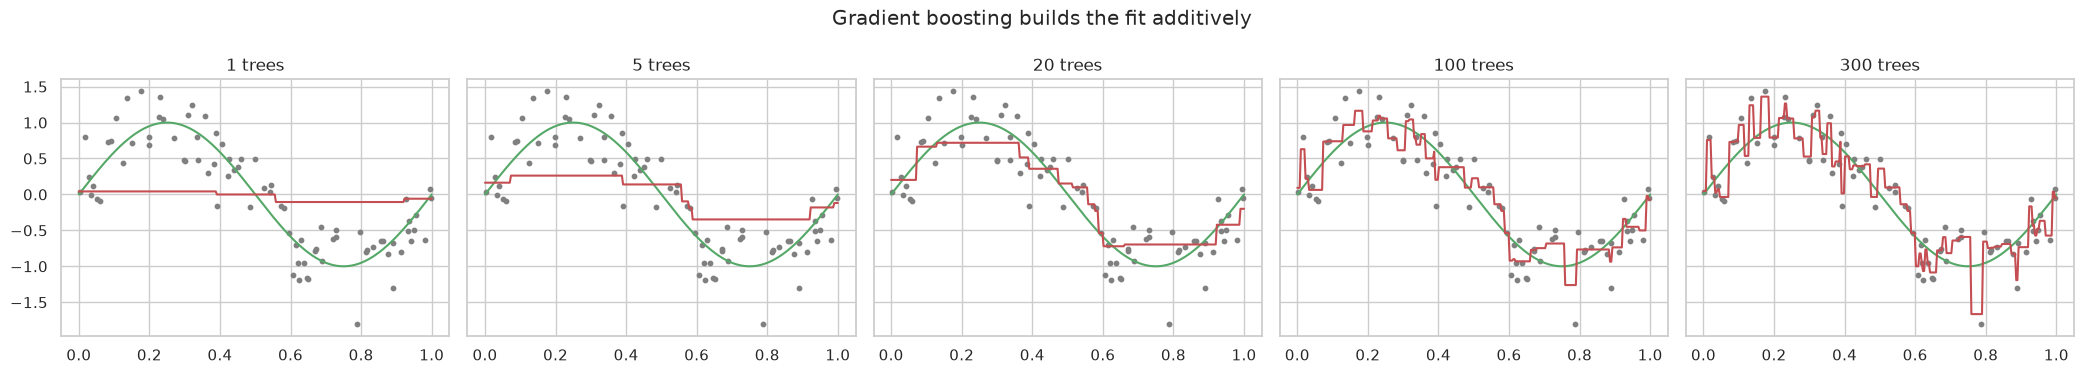

matches sklearn GradientBoostingRegressor: True


In [5]:
# Gradient boosting for regression, from scratch (squared loss → fit residuals)
class MyGradientBoosting:
    def __init__(self, n_rounds=100, lr=0.1, depth=2): self.M, self.lr, self.depth = n_rounds, lr, depth
    def fit(self, X, y):
        self.f0 = y.mean(); F = np.full(len(y), self.f0); self.trees = []
        for _ in range(self.M):
            tree = DecisionTreeRegressor(max_depth=self.depth).fit(X, y - F)          # negative gradient of 1/2 (y-F)^2 is the residual
            F = F + self.lr * tree.predict(X); self.trees.append(tree)
        return self
    def predict(self, X, m=None): return self.f0 + self.lr * sum(t.predict(X) for t in self.trees[:m or self.M])

gb = MyGradientBoosting(300).fit(x[:, None], t)
fig, ax = plt.subplots(1, 5, figsize=(21, 3.8), sharey=True)
for a_, m in zip(ax, [1, 5, 20, 100, 300]):
    a_.plot(xg, np.sin(2 * np.pi * xg), "g"); a_.plot(xg, gb.predict(xg, m), "r"); a_.scatter(x, t, s=10, c="gray"); a_.set_title(f"{m} trees")
plt.suptitle("Gradient boosting builds the fit additively"); plt.tight_layout(); plt.show()
print("matches sklearn GradientBoostingRegressor:", np.allclose(gb.predict(xg, 100), GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2, random_state=0).fit(x[:, None], t).predict(xg), atol=1e-6))

### A4. Generalised additive models (GAMs)
$g(\mathbb E[y])=\beta_0+\sum_jf_j(x_j)$: each feature gets its own smooth, learnable shape function $f_j$ (here a penalised spline basis), keeping interpretability while capturing non-linearity.
Fitting = a linear/GLM on spline bases with a ridge penalty (equivalent to a penalised-regression GAM). Data: $y=\sin(2x_1)+x_2^2+0.3\,x_3+\varepsilon$, with $x_3$ truly linear.

test R²  linear = 0.125   GAM = 0.940


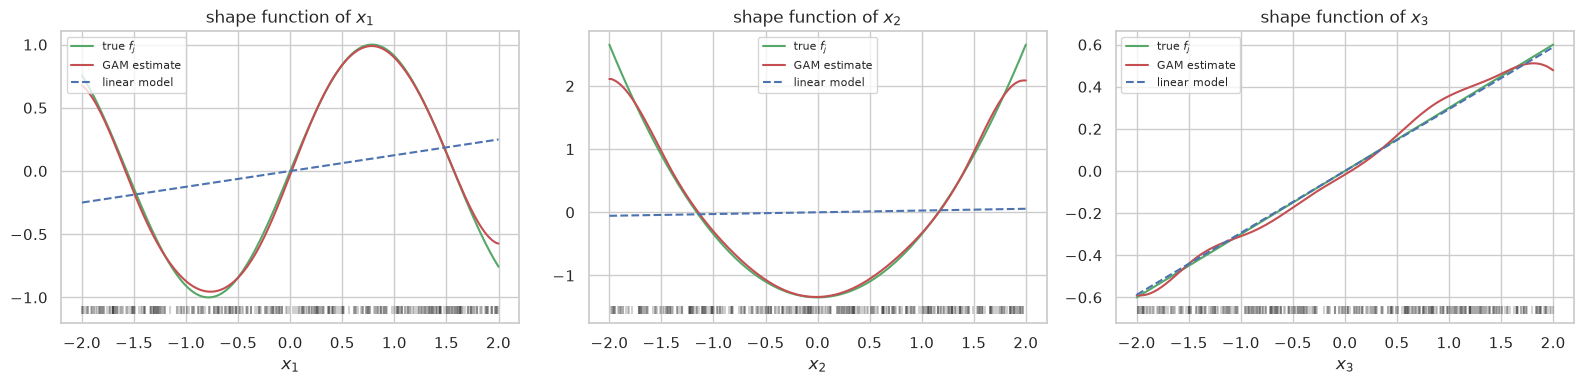

In [6]:
rng = np.random.default_rng(0); N = 600
Xg = rng.uniform(-2, 2, (N, 3)); yg = np.sin(2 * Xg[:, 0]) + Xg[:, 1] ** 2 + 0.3 * Xg[:, 2] + rng.normal(0, 0.3, N)
Xg_tr, Xg_te, yg_tr, yg_te = train_test_split(Xg, yg, test_size=0.3, random_state=0)

spl = lambda: SplineTransformer(n_knots=8, degree=3, include_bias=False)
gam = make_pipeline(ColumnTransformer([(f"s{j}", spl(), [j]) for j in range(3)]), Ridge(alpha=1.0)).fit(Xg_tr, yg_tr)
lin = LinearRegression().fit(Xg_tr, yg_tr)
print(f"test R²  linear = {lin.score(Xg_te, yg_te):.3f}   GAM = {gam.score(Xg_te, yg_te):.3f}")

# shape functions: vary one feature, hold the others at their mean (additivity ⇒ the curve is exactly f_j up to a constant)
grid = np.linspace(-2, 2, 200); truth = [lambda v: np.sin(2 * v), lambda v: v ** 2, lambda v: 0.3 * v]
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for j in range(3):
    Z = np.tile(Xg_tr.mean(0), (200, 1)); Z[:, j] = grid; f = gam.predict(Z); f -= f.mean()
    tj = truth[j](grid); ax[j].plot(grid, tj - tj.mean(), "g", label="true $f_j$"); ax[j].plot(grid, f, "r", label="GAM estimate"); ax[j].plot(grid, lin.coef_[j] * grid - (lin.coef_[j] * grid).mean(), "b--", label="linear model")
    ax[j].scatter(Xg_tr[:, j], np.full(len(Xg_tr), ax[j].get_ylim()[0]), marker="|", c="k", alpha=.2); ax[j].set(title=f"shape function of $x_{j+1}$", xlabel=f"$x_{j+1}$"); ax[j].legend(fontsize=8)
plt.tight_layout(); plt.show()

### A5. CART — Classification And Regression Trees
CART greedily partitions the input space with axis-aligned splits $x_j\le s$. At each node choose the split that maximally reduces **impurity**; for classification the Gini index is
$G=1-\sum_kp_k^2$ (entropy $-\sum p_k\ln p_k$ is an alternative). Recursion stops at a depth/size limit or purity; **cost-complexity pruning** ($R_\alpha(T)=R(T)+\alpha|T|$) removes weak branches.
The implementation is in Practice 1 below.

---
## Part B — Practice

## Practice 1 — Implement CART to perform categorisation
Plan: (1) implement a CART classifier from scratch (Gini, exhaustive best-split search, recursion, pruning by depth/leaf size), (2) check it against scikit-learn,
(3) visualise tree, decision regions and feature importances, (4) study depth/over-fitting and cost-complexity pruning, (5) evaluate on a real data set.

In [7]:
class MyCART:
    """Classification tree (Gini impurity, binary axis-aligned splits)."""
    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1, criterion="gini"):
        self.max_depth, self.min_split, self.min_leaf, self.criterion = max_depth, min_samples_split, min_samples_leaf, criterion

    def _impurity(self, counts):                       # counts: (..., n_classes)
        p = counts / np.maximum(counts.sum(-1, keepdims=True), 1)
        if self.criterion == "gini": return 1 - (p ** 2).sum(-1)
        return -(p * np.log2(np.where(p > 0, p, 1))).sum(-1)

    def _best_split(self, X, y):
        n, d = X.shape; total = np.bincount(y, minlength=self.K_); parent = self._impurity(total); best = (None, None, 0.0)
        Y = np.eye(self.K_)[y]
        for j in range(d):
            order = np.argsort(X[:, j], kind="stable"); xs = X[order, j]; left = np.cumsum(Y[order], 0)[:-1]; right = total - left
            nl = np.arange(1, n); nr = n - nl
            gain = parent - (nl * self._impurity(left) + nr * self._impurity(right)) / n           # impurity decrease for every cut point
            ok = (xs[:-1] != xs[1:]) & (nl >= self.min_leaf) & (nr >= self.min_leaf)
            if ok.any():
                i = np.argmax(np.where(ok, gain, -np.inf))
                if gain[i] > best[2] + 1e-12: best = (j, (xs[i] + xs[i + 1]) / 2, gain[i])
        return best

    def _grow(self, X, y, depth):
        counts = np.bincount(y, minlength=self.K_); node = dict(counts=counts, n=len(y), impurity=self._impurity(counts), depth=depth)
        if (self.max_depth is not None and depth >= self.max_depth) or len(y) < self.min_split or node["impurity"] == 0: return node
        j, s, gain = self._best_split(X, y)
        if j is None: return node
        m = X[:, j] <= s; node.update(feature=j, threshold=s, gain=gain * len(y))
        node["left"], node["right"] = self._grow(X[m], y[m], depth + 1), self._grow(X[~m], y[~m], depth + 1); return node

    def fit(self, X, y):
        X = np.asarray(X, float); y = np.asarray(y); self.classes_, y = np.unique(y, return_inverse=True); self.K_ = len(self.classes_); self.d_ = X.shape[1]
        self.tree_ = self._grow(X, y, 0); return self

    def _leaf(self, x):
        node = self.tree_
        while "left" in node: node = node["left"] if x[node["feature"]] <= node["threshold"] else node["right"]
        return node
    def predict_proba(self, X): return np.array([self._leaf(x)["counts"] / self._leaf(x)["counts"].sum() for x in np.asarray(X, float)])
    def predict(self, X): return self.classes_[self.predict_proba(X).argmax(1)]
    def score(self, X, y): return np.mean(self.predict(X) == np.asarray(y))

    def _walk(self, node=None):
        node = node or self.tree_; yield node
        if "left" in node: yield from self._walk(node["left"]); yield from self._walk(node["right"])
    def depth(self): return max(n["depth"] for n in self._walk())
    def n_leaves(self): return sum("left" not in n for n in self._walk())
    def feature_importances_(self):
        imp = np.zeros(self.d_)
        for nd in self._walk():
            if "left" in nd: imp[nd["feature"]] += nd["gain"]
        return imp / imp.sum()

    def to_text(self, names, node=None, indent=""):
        node = node or self.tree_
        if "left" not in node: return f"{indent}→ class {self.classes_[node['counts'].argmax()]}  {node['counts'].tolist()}\n"
        s = f"{indent}if {names[node['feature']]} <= {node['threshold']:.3f}:\n" + self.to_text(names, node["left"], indent + "    ")
        return s + f"{indent}else:  # {names[node['feature']]} > {node['threshold']:.3f}\n" + self.to_text(names, node["right"], indent + "    ")

### Step 1 – Iris: fit, print the learned rules, compare with scikit-learn

In [8]:
iris = load_iris(as_frame=True); Xi, yi = iris.data, iris.target
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(Xi, yi, test_size=0.3, stratify=yi, random_state=1)

mine = MyCART(max_depth=3).fit(Xi_tr, yi_tr); ref = DecisionTreeClassifier(max_depth=3, random_state=0).fit(Xi_tr, yi_tr)
print(f"test accuracy:  scratch CART = {mine.score(Xi_te, yi_te):.3f}    sklearn = {ref.score(Xi_te, yi_te):.3f}    predictions identical: {np.array_equal(mine.predict(Xi_te), ref.predict(Xi_te))}")
print(f"depth={mine.depth()}  leaves={mine.n_leaves()}   (sklearn depth={ref.get_depth()} leaves={ref.get_n_leaves()})")
print("\nLearned rules (scratch implementation):\n" + mine.to_text(list(Xi.columns)))

test accuracy:  scratch CART = 0.978    sklearn = 0.978    predictions identical: True
depth=3  leaves=4   (sklearn depth=3 leaves=4)

Learned rules (scratch implementation):
if petal length (cm) <= 2.600:
    → class 0  [35, 0, 0]
else:  # petal length (cm) > 2.600
    if petal length (cm) <= 4.750:
        → class 1  [0, 30, 0]
    else:  # petal length (cm) > 4.750
        if petal width (cm) <= 1.750:
            → class 1  [0, 4, 4]
        else:  # petal width (cm) > 1.750
            → class 2  [0, 1, 31]



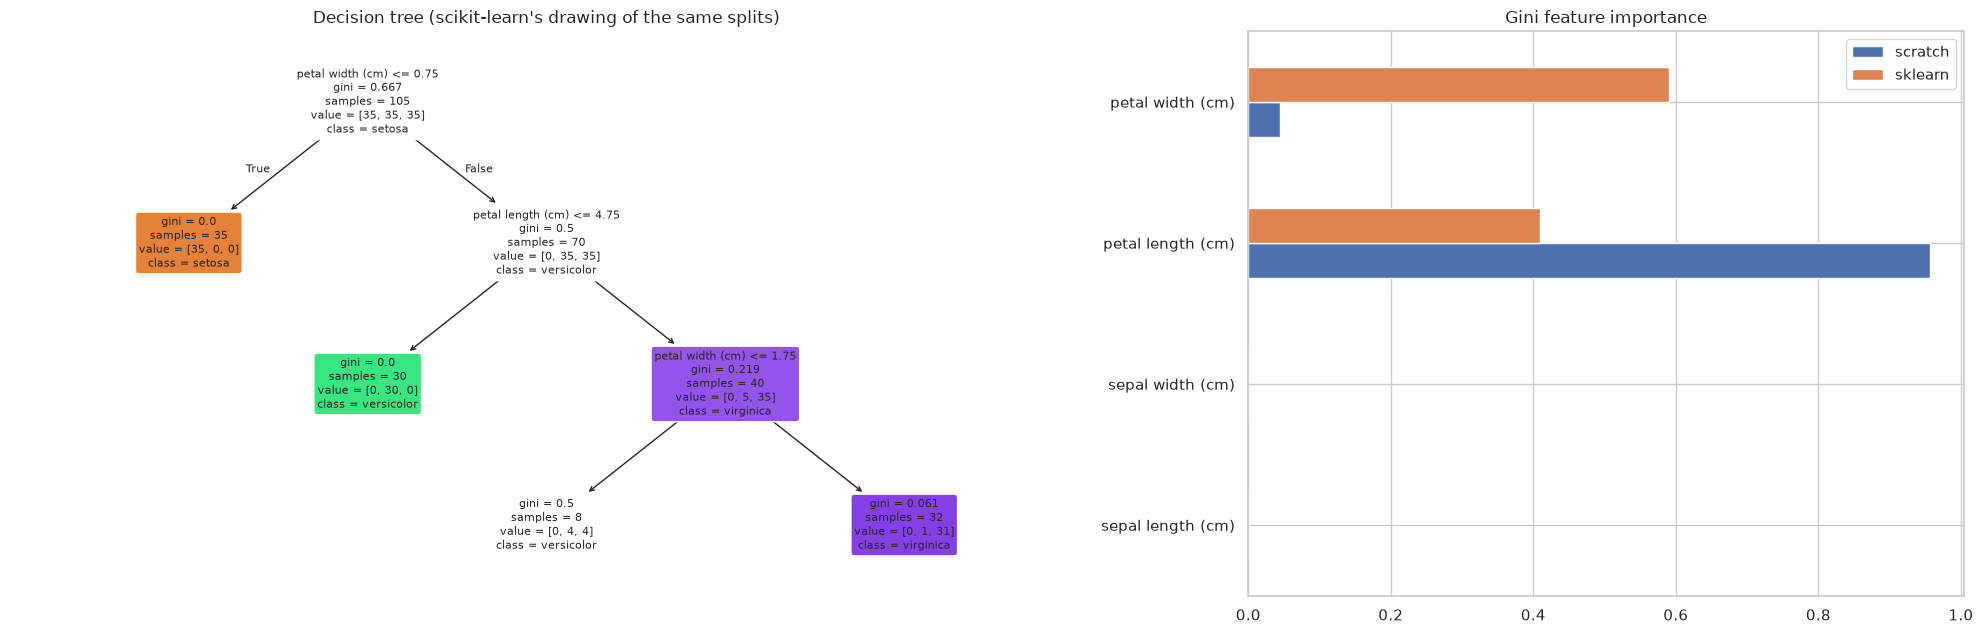

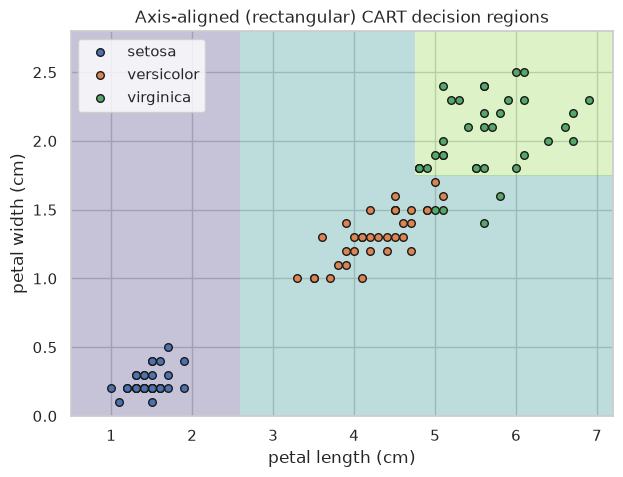

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(20, 6.5), gridspec_kw={"width_ratios": [1.5, 1]})
plot_tree(ref, feature_names=Xi.columns, class_names=iris.target_names, filled=True, rounded=True, impurity=True, fontsize=8, ax=ax[0]); ax[0].set_title("Decision tree (scikit-learn's drawing of the same splits)")
imp = pd.DataFrame({"scratch": mine.feature_importances_(), "sklearn": ref.feature_importances_}, index=Xi.columns); imp.plot.barh(ax=ax[1]); ax[1].set_title("Gini feature importance"); plt.tight_layout(); plt.show()

# decision regions in the 2-D petal space
cols = ["petal length (cm)", "petal width (cm)"]; t2 = MyCART(max_depth=3).fit(Xi_tr[cols], yi_tr)
g0, g1 = np.meshgrid(np.linspace(0.5, 7.2, 300), np.linspace(0, 2.8, 300)); Z = t2.predict(np.c_[g0.ravel(), g1.ravel()]).reshape(g0.shape)
plt.figure(figsize=(7, 5)); plt.contourf(g0, g1, Z, alpha=.3, cmap="viridis", levels=[-.5, .5, 1.5, 2.5])
for k, nme in enumerate(iris.target_names): m = yi_tr == k; plt.scatter(Xi_tr.loc[m, cols[0]], Xi_tr.loc[m, cols[1]], label=nme, edgecolor="k", s=30)
plt.xlabel(cols[0]); plt.ylabel(cols[1]); plt.legend(); plt.title("Axis-aligned (rectangular) CART decision regions"); plt.show()

### Step 2 – Gini vs. entropy, depth and over-fitting, cost-complexity pruning (breast-cancer data)

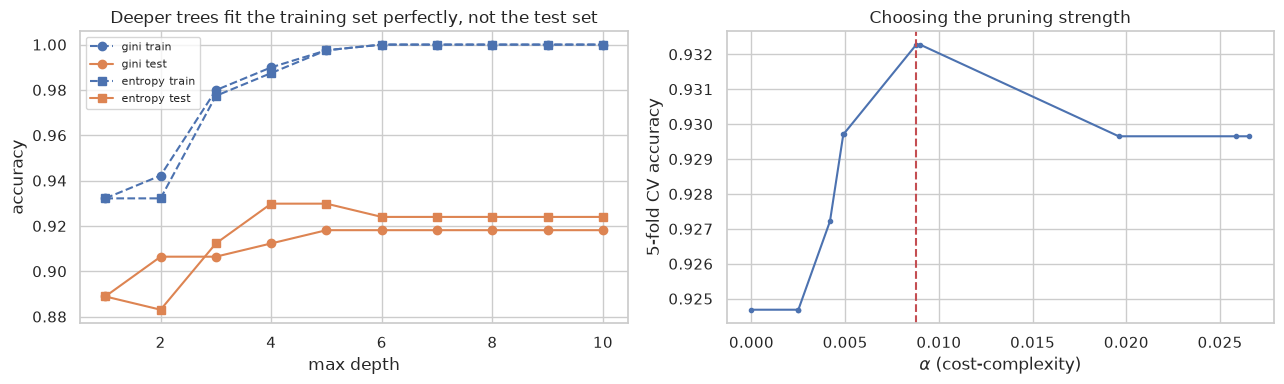

                   leaves  train acc  test acc
unpruned               16      1.000     0.906
pruned (α=0.0088)       6      0.977     0.918


In [10]:
bc = load_breast_cancer(as_frame=True); Xb, yb = bc.data, bc.target
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xb, yb, test_size=0.3, stratify=yb, random_state=0)

depths = range(1, 11); rows = []
for d in depths:
    for crit in ["gini", "entropy"]:
        m = MyCART(max_depth=d, criterion=crit).fit(Xb_tr, yb_tr); rows.append((d, crit, m.score(Xb_tr, yb_tr), m.score(Xb_te, yb_te)))
res = pd.DataFrame(rows, columns=["depth", "criterion", "train", "test"])
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for crit, mk in [("gini", "o"), ("entropy", "s")]:
    r = res[res.criterion == crit]; ax[0].plot(r.depth, r.train, mk + "--", c="C0", label=f"{crit} train"); ax[0].plot(r.depth, r.test, mk + "-", c="C1", label=f"{crit} test")
ax[0].set(xlabel="max depth", ylabel="accuracy", title="Deeper trees fit the training set perfectly, not the test set"); ax[0].legend(fontsize=8)

path = DecisionTreeClassifier(random_state=0).fit(Xb_tr, yb_tr).cost_complexity_pruning_path(Xb_tr, yb_tr); alphas = path.ccp_alphas[:-1]
cv = [cross_val_score(DecisionTreeClassifier(ccp_alpha=a, random_state=0), Xb_tr, yb_tr, cv=5).mean() for a in alphas]
best_a = alphas[int(np.argmax(cv))]
ax[1].plot(alphas, cv, "o-", ms=3); ax[1].axvline(best_a, c="r", ls="--"); ax[1].set(xlabel=r"$\alpha$ (cost-complexity)", ylabel="5-fold CV accuracy", title="Choosing the pruning strength"); plt.tight_layout(); plt.show()

full = DecisionTreeClassifier(random_state=0).fit(Xb_tr, yb_tr); pruned = DecisionTreeClassifier(ccp_alpha=best_a, random_state=0).fit(Xb_tr, yb_tr)
print(pd.DataFrame({"leaves": [full.get_n_leaves(), pruned.get_n_leaves()], "train acc": [full.score(Xb_tr, yb_tr), pruned.score(Xb_tr, yb_tr)], "test acc": [full.score(Xb_te, yb_te), pruned.score(Xb_te, yb_te)]}, index=["unpruned", f"pruned (α={best_a:.4f})"]).round(3).to_string())

chosen depth = 2   test accuracy = 0.906   AUC = 0.942


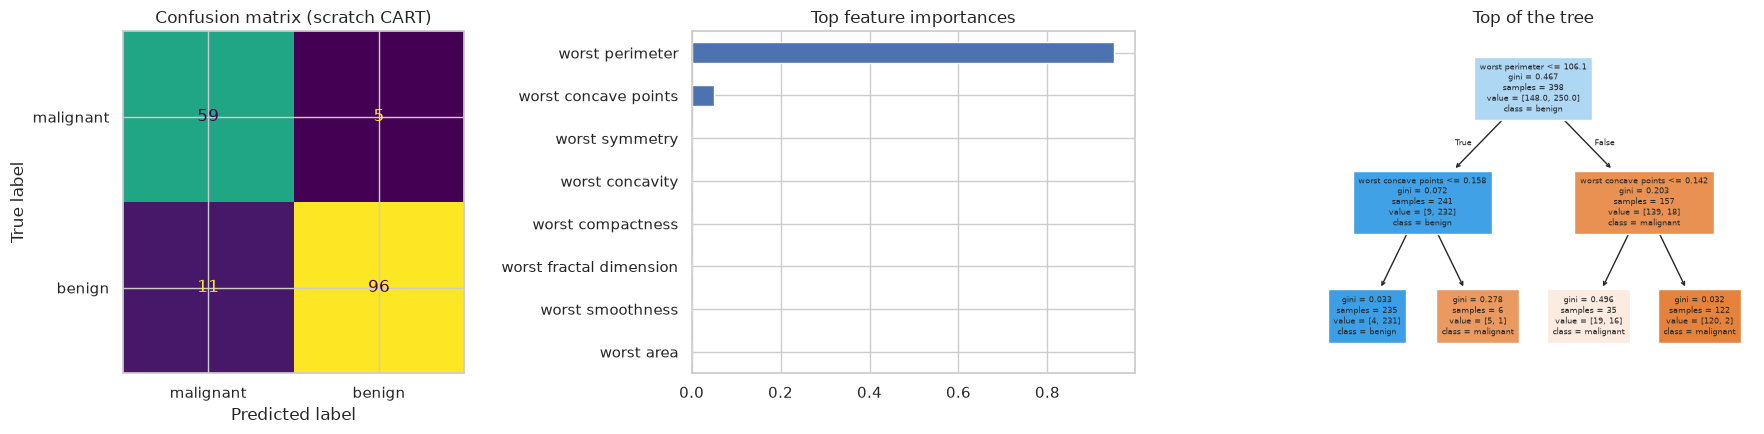

|--- worst perimeter <= 106.10
|   |--- worst concave points <= 0.16
|   |   |--- class: 1
|   |--- worst concave points >  0.16
|   |   |--- class: 0
|--- worst perimeter >  106.10
|   |--- worst concave points <= 0.14
|   |   |--- class: 0
|   |--- worst concave points >  0.14
|   |   |--- class: 0



In [11]:
# final CART evaluation: scratch tree with the CV-chosen depth
cv_d = {d: cross_val_score(DecisionTreeClassifier(max_depth=d, random_state=0), Xb_tr, yb_tr, cv=5).mean() for d in depths}; d_best = max(cv_d, key=cv_d.get)
final = MyCART(max_depth=d_best).fit(Xb_tr, yb_tr); pred = final.predict(Xb_te)
print(f"chosen depth = {d_best}   test accuracy = {accuracy_score(yb_te, pred):.3f}   AUC = {roc_auc_score(yb_te, final.predict_proba(Xb_te)[:, 1]):.3f}")
fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
ConfusionMatrixDisplay(confusion_matrix(yb_te, pred), display_labels=bc.target_names).plot(ax=ax[0], colorbar=False); ax[0].set_title("Confusion matrix (scratch CART)")
imp = pd.Series(final.feature_importances_(), index=Xb.columns).sort_values().tail(8); imp.plot.barh(ax=ax[1]); ax[1].set_title("Top feature importances")
plot_tree(DecisionTreeClassifier(max_depth=min(d_best, 3), random_state=0).fit(Xb_tr, yb_tr), feature_names=Xb.columns, class_names=bc.target_names, filled=True, fontsize=6, ax=ax[2]); ax[2].set_title("Top of the tree")
plt.tight_layout(); plt.show()
print(export_text(DecisionTreeClassifier(max_depth=2, random_state=0).fit(Xb_tr, yb_tr), feature_names=list(Xb.columns)))

### Step 3 – Instability of a single tree (motivation for ensembles)
A small change in the training data can change the tree substantially — CART has low bias but **high variance**.

most common root splits over 40 bootstrap resamples:
(worst perimeter, 114.45)       4
(worst concave points, 0.15)    4
(worst radius, 16.82)           3
(mean concave points, 0.05)     3
(worst perimeter, 106.1)        2
(worst concave points, 0.12)    2
(mean concave points, 0.06)     2
(worst concave points, 0.13)    2


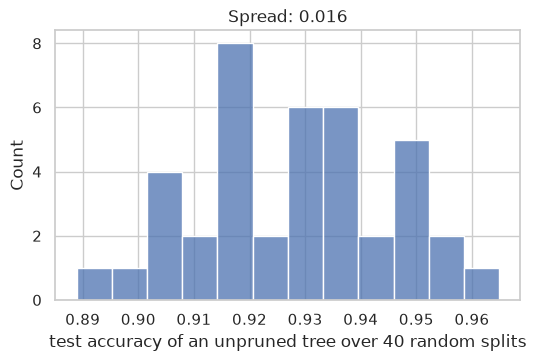

In [12]:
roots = []
for seed in range(40):
    i = np.random.default_rng(seed).integers(0, len(Xb_tr), len(Xb_tr)); tr = DecisionTreeClassifier(max_depth=3, random_state=0).fit(Xb_tr.iloc[i], yb_tr.iloc[i])
    roots.append((Xb.columns[tr.tree_.feature[0]], round(tr.tree_.threshold[0], 2)))
print("most common root splits over 40 bootstrap resamples:"); print(pd.Series(roots).value_counts().head(8).to_string())
accs = []
for seed in range(40):
    Xs, Xt, ys, yt = train_test_split(Xb, yb, test_size=0.3, random_state=seed); accs.append(DecisionTreeClassifier(random_state=0).fit(Xs, ys).score(Xt, yt))
plt.figure(figsize=(6, 3.5)); sns.histplot(accs, bins=12); plt.xlabel("test accuracy of an unpruned tree over 40 random splits"); plt.title(f"Spread: {np.std(accs):.3f}"); plt.show()

## Practice 2 — Implement ensemble learning models for classification
We build and compare the main ensemble families on the breast-cancer data (569 samples, 30 features):

| family | idea | models |
|---|---|---|
| **Bagging** | average decorrelated, high-variance models | Bagging, Random Forest, Extra-Trees |
| **Boosting** | sequentially correct errors | AdaBoost, Gradient Boosting, HistGradientBoosting |
| **Voting** | combine heterogeneous models | hard & soft voting |
| **Stacking** | learn how to combine models | meta logistic regression |

### Step 0 – Why ensembles work (Condorcet's jury theorem)
If $n$ classifiers are each correct with probability $p>0.5$ **and independent**, the majority vote is correct with probability $\sum_{k>n/2}\binom nk p^k(1-p)^{n-k}\to1$.
Correlated errors weaken this — which is why *diversity* matters (bootstrap, random feature subsets, different model types).

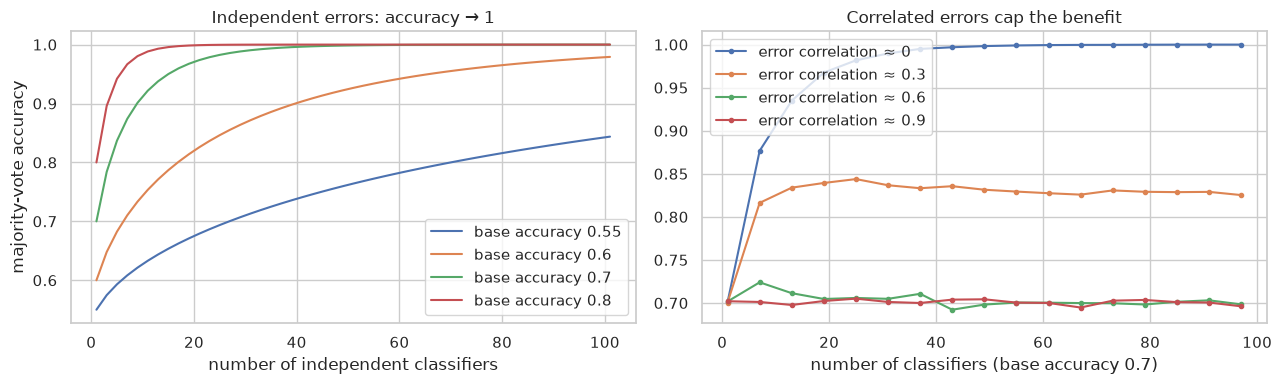

In [13]:
def majority_acc(n, p): return sum(comb(n, k) * p ** k * (1 - p) ** (n - k) for k in range(n // 2 + 1, n + 1))
ns = np.arange(1, 102, 2)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for p in [.55, .6, .7, .8]: ax[0].plot(ns, [majority_acc(k, p) for k in ns], label=f"base accuracy {p}")
ax[0].set(xlabel="number of independent classifiers", ylabel="majority-vote accuracy", title="Independent errors: accuracy → 1"); ax[0].legend()

rng = np.random.default_rng(0)                                         # correlated voters: each classifier follows a shared 'signal' with prob. rho
for rho in [0, .3, .6, .9]:
    accs = []
    for k in ns[::3]:
        common = rng.random(20000) < .7; indep = rng.random((20000, k)) < .7
        use_common = rng.random((20000, k)) < rho; votes = np.where(use_common, common[:, None], indep); accs.append(np.mean(votes.sum(1) > k / 2))
    ax[1].plot(ns[::3], accs, "o-", ms=3, label=f"error correlation ≈ {rho}")
ax[1].set(xlabel="number of classifiers (base accuracy 0.7)", title="Correlated errors cap the benefit"); ax[1].legend(); plt.tight_layout(); plt.show()

### Step 1 – Build the models and cross-validate

,0,1,2,3,4,mean,std
Decision tree,0.8953,0.9176,0.9294,0.9059,0.9176,0.9132,0.0130
Naive Bayes,0.8721,0.9647,0.9647,0.9294,0.9412,0.9344,0.0380
Bagging (trees),0.9070,0.9647,0.9412,0.9529,0.9529,0.9437,0.0222
Gradient boosting,0.9302,0.9765,0.9412,0.9529,0.9412,0.9484,0.0176
Random forest,0.9302,0.9765,0.9529,0.9529,0.9412,0.9508,0.0172
HistGradientBoosting,0.9186,0.9647,0.9765,0.9529,0.9647,0.9555,0.0222
Extra-trees,0.9302,0.9765,0.9647,0.9647,0.9529,0.9578,0.0175
k-NN,0.9535,0.9647,0.9529,0.9765,0.9647,0.9625,0.0097
Voting (hard),0.9419,0.9765,0.9765,0.9765,0.9647,0.9672,0.0151
Voting (soft),0.9419,0.9765,0.9765,0.9765,0.9647,0.9672,0.0151


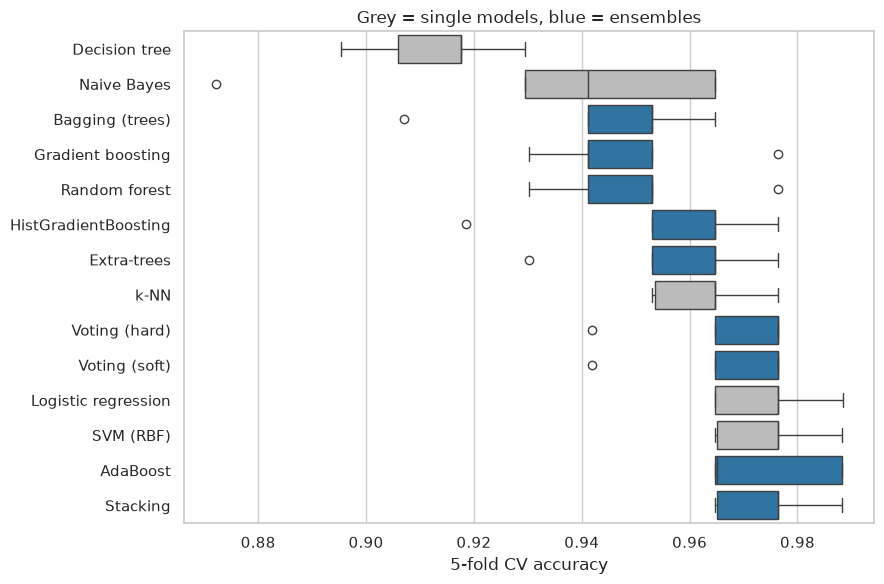

In [14]:
Xtr, Xte, ytr, yte = train_test_split(Xb, yb, test_size=0.25, stratify=yb, random_state=42)
skf = StratifiedKFold(5, shuffle=True, random_state=0)
scaled = lambda m: make_pipeline(StandardScaler(), m)

base = {"Decision tree": DecisionTreeClassifier(random_state=0),
        "Logistic regression": scaled(LogisticRegression(max_iter=2000)),
        "SVM (RBF)": scaled(CalibratedClassifierCV(SVC(), cv=5)),         # calibrated SVM → gives probabilities
        "k-NN": scaled(KNeighborsClassifier(7)),
        "Naive Bayes": GaussianNB()}
ensembles = {"Bagging (trees)": BaggingClassifier(DecisionTreeClassifier(), n_estimators=100, random_state=0),
             "Random forest": RandomForestClassifier(300, random_state=0),
             "Extra-trees": ExtraTreesClassifier(300, random_state=0),
             "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=0),
             "Gradient boosting": GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=0),
             "HistGradientBoosting": HistGradientBoostingClassifier(random_state=0)}
estimators = [("lr", base["Logistic regression"]), ("svm", base["SVM (RBF)"]), ("rf", ensembles["Random forest"]), ("gb", ensembles["Gradient boosting"])]
ensembles["Voting (hard)"] = VotingClassifier(estimators, voting="hard")
ensembles["Voting (soft)"] = VotingClassifier(estimators, voting="soft")
ensembles["Stacking"] = StackingClassifier(estimators, final_estimator=LogisticRegression(max_iter=2000), cv=5)
models = {**base, **ensembles}

cv_scores = {k: cross_val_score(m, Xtr, ytr, cv=skf, scoring="accuracy") for k, m in models.items()}
cv_df = pd.DataFrame(cv_scores).T; cv_df["mean"] = cv_df.mean(axis=1); cv_df["std"] = cv_df.iloc[:, :5].std(axis=1); cv_df = cv_df.sort_values("mean")
display(cv_df.round(4))
plt.figure(figsize=(9, 6)); order = cv_df.index; data = pd.DataFrame(cv_scores)[order]
colors = ["#bbbbbb" if k in base else PAL[0] for k in order]
sns.boxplot(data=data, orient="h", palette=colors, order=list(order))
plt.xlabel("5-fold CV accuracy"); plt.title("Grey = single models, blue = ensembles"); plt.tight_layout(); plt.show()

### Step 2 – Hold-out test performance

,accuracy,AUC,errors
Logistic regression,0.9860,0.9977,2.0
Stacking,0.9860,0.9973,2.0
SVM (RBF),0.9790,0.9966,3.0
k-NN,0.9790,0.9923,3.0
Voting (hard),0.9790,NaN,3.0
HistGradientBoosting,0.9720,0.9931,4.0
AdaBoost,0.9720,0.9901,4.0
Extra-trees,0.9650,0.9961,5.0
Voting (soft),0.9580,0.9971,6.0
Random forest,0.9580,0.9947,6.0


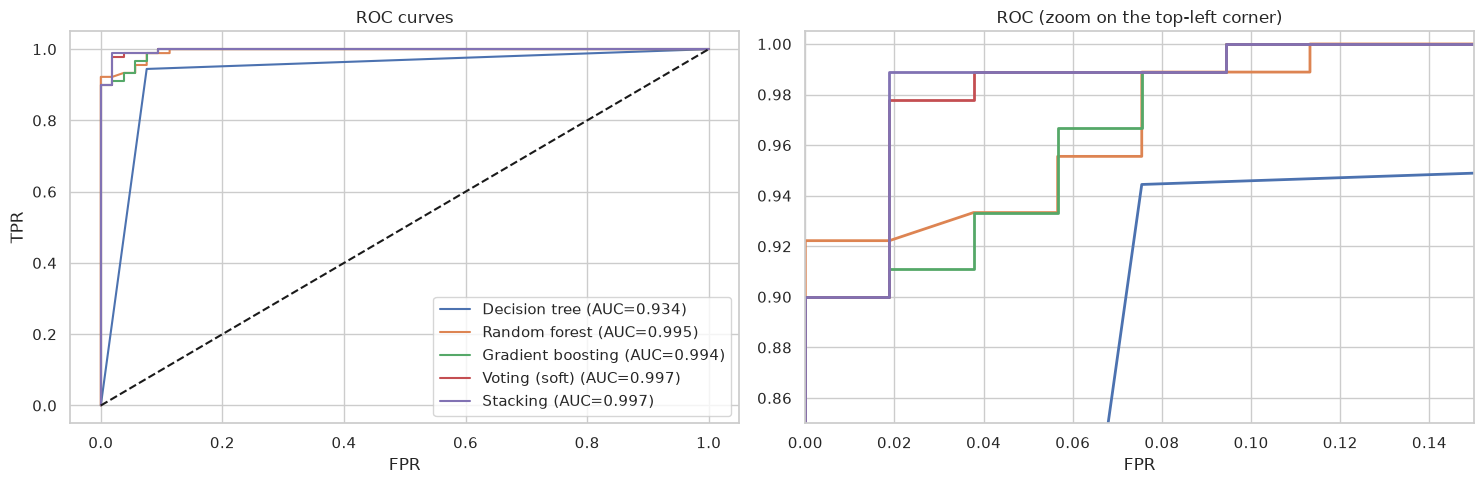

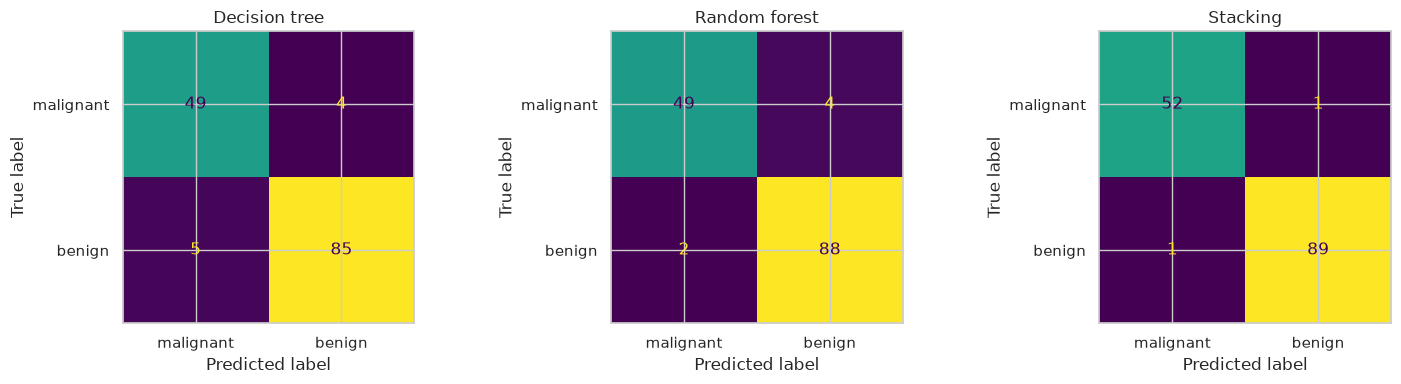

In [15]:
fitted = {k: m.fit(Xtr, ytr) for k, m in models.items()}
rows = {}
for k, m in fitted.items():
    pr = m.predict(Xte); sc = m.predict_proba(Xte)[:, 1] if hasattr(m, "predict_proba") else None
    rows[k] = dict(accuracy=accuracy_score(yte, pr), AUC=roc_auc_score(yte, sc) if sc is not None else np.nan, errors=int((pr != yte).sum()))
test = pd.DataFrame(rows).T.sort_values(["accuracy", "AUC"], ascending=False); display(test.round(4))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
for k in ["Decision tree", "Random forest", "Gradient boosting", "Voting (soft)", "Stacking"]:
    f, t_, _ = roc_curve(yte, fitted[k].predict_proba(Xte)[:, 1]); ax[0].plot(f, t_, label=f"{k} (AUC={roc_auc_score(yte, fitted[k].predict_proba(Xte)[:, 1]):.3f})")
ax[0].plot([0, 1], [0, 1], "k--"); ax[0].set(xlabel="FPR", ylabel="TPR", title="ROC curves"); ax[0].legend(loc="lower right")
for k in ["Decision tree", "Random forest", "Gradient boosting", "Voting (soft)", "Stacking"]:
    f, t_, _ = roc_curve(yte, fitted[k].predict_proba(Xte)[:, 1]); ax[1].plot(f, t_, lw=2)
ax[1].set(xlim=(0, .15), ylim=(.85, 1.005), xlabel="FPR", title="ROC (zoom on the top-left corner)"); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a_, k in zip(ax, ["Decision tree", "Random forest", "Stacking"]):
    ConfusionMatrixDisplay(confusion_matrix(yte, fitted[k].predict(Xte)), display_labels=bc.target_names).plot(ax=a_, colorbar=False); a_.set_title(k)
plt.tight_layout(); plt.show()

**Reading the results.** Every ensemble clearly improves on the single decision tree (CV accuracy ≈ 0.91 → 0.94–0.97; AUC 0.93 → 0.99+) — that is the variance reduction of bagging and the bias reduction of boosting at work.
On this particular data set, however, the classes are almost linearly separable after scaling, so well-regularised *single* models (logistic regression, RBF-SVM) are already as good as the best ensembles; differences among the top models are within about one test sample, i.e. well inside the CV standard deviation.
Stacking and voting inherit the strengths of their best members without having to know in advance which one that is. Which family wins is data-dependent — hence the value of comparing under cross-validation.

### Step 3 – Looking inside: a bagging implementation from scratch, out-of-bag error, and feature importance
Bagging from scratch: bootstrap → fit tree → majority vote. The ~37 % of samples left out of each bootstrap give a free **out-of-bag (OOB)** error estimate.

bagging (all features)                        OOB acc = 0.948   test acc = 0.951


random-forest style (√d features per split)   OOB acc = 0.960   test acc = 0.958


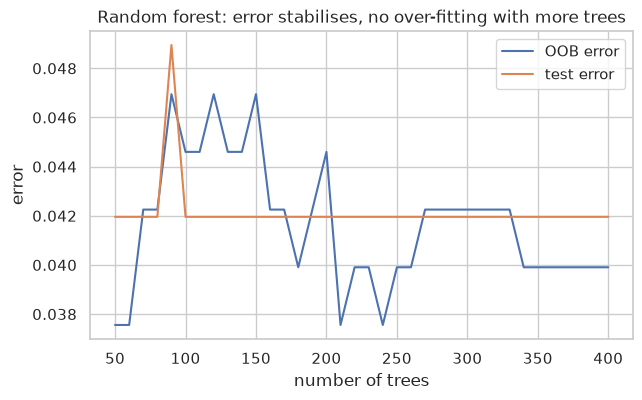

In [16]:
class MyBagging:
    def __init__(self, n_estimators=100, max_features=None, seed=0): self.B, self.mf, self.seed = n_estimators, max_features, seed
    def fit(self, X, y):
        X, y = np.asarray(X), np.asarray(y); r = np.random.default_rng(self.seed); N = len(X); self.trees = []; self.oob_masks = []
        for b in range(self.B):
            i = r.integers(0, N, N); self.trees.append(DecisionTreeClassifier(max_features=self.mf, random_state=int(r.integers(1 << 30))).fit(X[i], y[i]))
            m = np.ones(N, bool); m[i] = False; self.oob_masks.append(m)
        # OOB votes
        votes = np.zeros((N, 2))
        for t, m in zip(self.trees, self.oob_masks): votes[np.where(m)[0], t.predict(X[m])] += 1
        seen = votes.sum(1) > 0; self.oob_acc_ = np.mean(votes[seen].argmax(1) == y[seen]); self._X, self._y = X, y; self._votes_hist = None
        return self
    def predict_proba(self, X): return np.mean([t.predict_proba(np.asarray(X)) for t in self.trees], axis=0)
    def predict(self, X): return self.predict_proba(X).argmax(1)

for name, mf in [("bagging (all features)", None), ("random-forest style (√d features per split)", "sqrt")]:
    mb = MyBagging(150, max_features=mf).fit(Xtr, ytr); print(f"{name:<45} OOB acc = {mb.oob_acc_:.3f}   test acc = {accuracy_score(yte, mb.predict(Xte)):.3f}")

# OOB error and test error vs. number of trees (sklearn forest, warm start)
rf = RandomForestClassifier(warm_start=True, oob_score=True, random_state=0); oob, tes = [], []
for B in range(50, 401, 10): rf.set_params(n_estimators=B); rf.fit(Xtr, ytr); oob.append(1 - rf.oob_score_); tes.append(1 - rf.score(Xte, yte))
plt.figure(figsize=(7, 4)); plt.plot(range(50, 401, 10), oob, label="OOB error"); plt.plot(range(50, 401, 10), tes, label="test error"); plt.xlabel("number of trees"); plt.ylabel("error"); plt.legend(); plt.title("Random forest: error stabilises, no over-fitting with more trees"); plt.show()

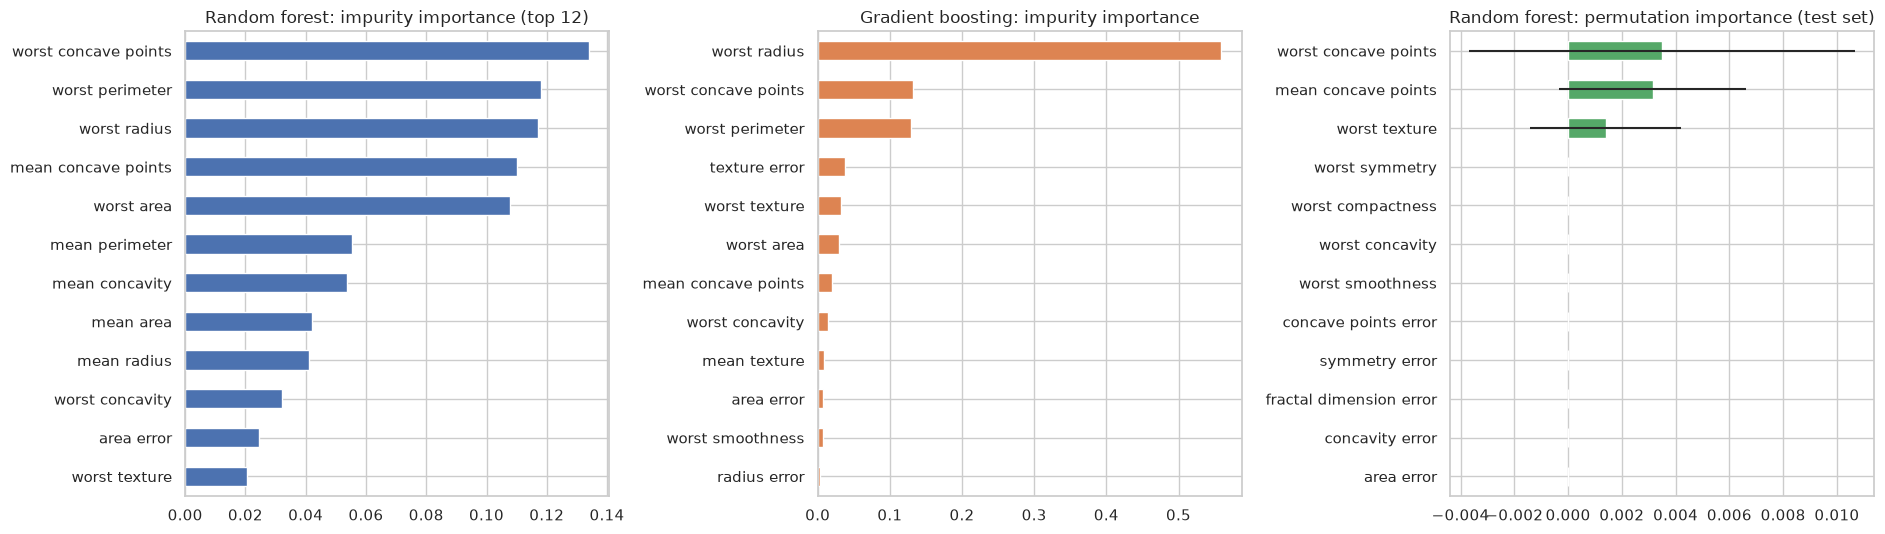

In [17]:
rf = fitted["Random forest"]; gb = fitted["Gradient boosting"]
pim = permutation_importance(rf, Xte, yte, n_repeats=20, random_state=0)
fig, ax = plt.subplots(1, 3, figsize=(19, 5.5))
pd.Series(rf.feature_importances_, index=Xb.columns).sort_values().tail(12).plot.barh(ax=ax[0]); ax[0].set_title("Random forest: impurity importance (top 12)")
pd.Series(gb.feature_importances_, index=Xb.columns).sort_values().tail(12).plot.barh(ax=ax[1], color="C1"); ax[1].set_title("Gradient boosting: impurity importance")
pd.Series(pim.importances_mean, index=Xb.columns).sort_values().tail(12).plot.barh(xerr=pd.Series(pim.importances_std, index=Xb.columns)[pd.Series(pim.importances_mean, index=Xb.columns).sort_values().tail(12).index], ax=ax[2], color="C2"); ax[2].set_title("Random forest: permutation importance (test set)")
plt.tight_layout(); plt.show()

### Step 4 – Hyper-parameters of boosting, and decision regions of different ensembles

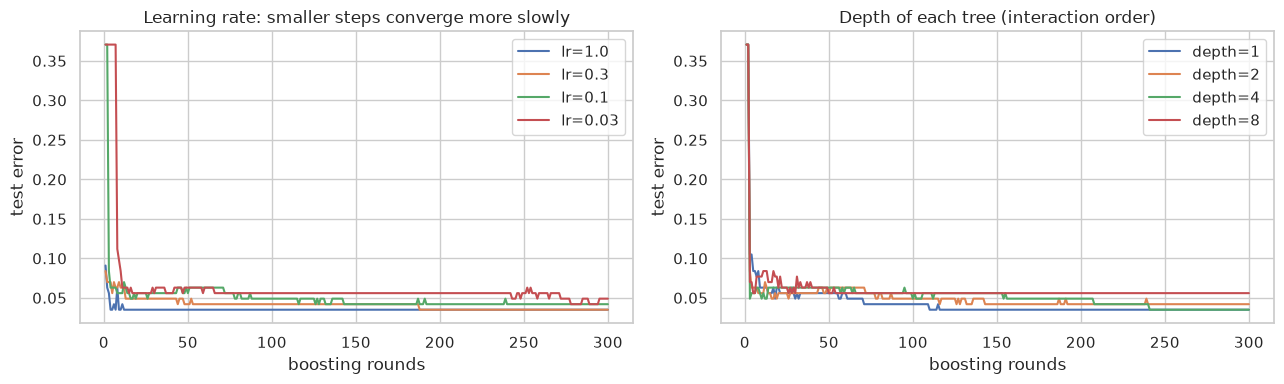

In [18]:
# learning rate × number of trees (staged test accuracy)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for lr in [1.0, 0.3, 0.1, 0.03]:
    g = GradientBoostingClassifier(n_estimators=300, learning_rate=lr, max_depth=2, random_state=0).fit(Xtr, ytr)
    ax[0].plot(range(1, 301), [1 - accuracy_score(yte, p) for p in g.staged_predict(Xte)], label=f"lr={lr}")
ax[0].set(xlabel="boosting rounds", ylabel="test error", title="Learning rate: smaller steps converge more slowly"); ax[0].legend()
for d in [1, 2, 4, 8]:
    g = GradientBoostingClassifier(n_estimators=300, learning_rate=0.1, max_depth=d, random_state=0).fit(Xtr, ytr)
    ax[1].plot(range(1, 301), [1 - accuracy_score(yte, p) for p in g.staged_predict(Xte)], label=f"depth={d}")
ax[1].set(xlabel="boosting rounds", ylabel="test error", title="Depth of each tree (interaction order)"); ax[1].legend(); plt.tight_layout(); plt.show()

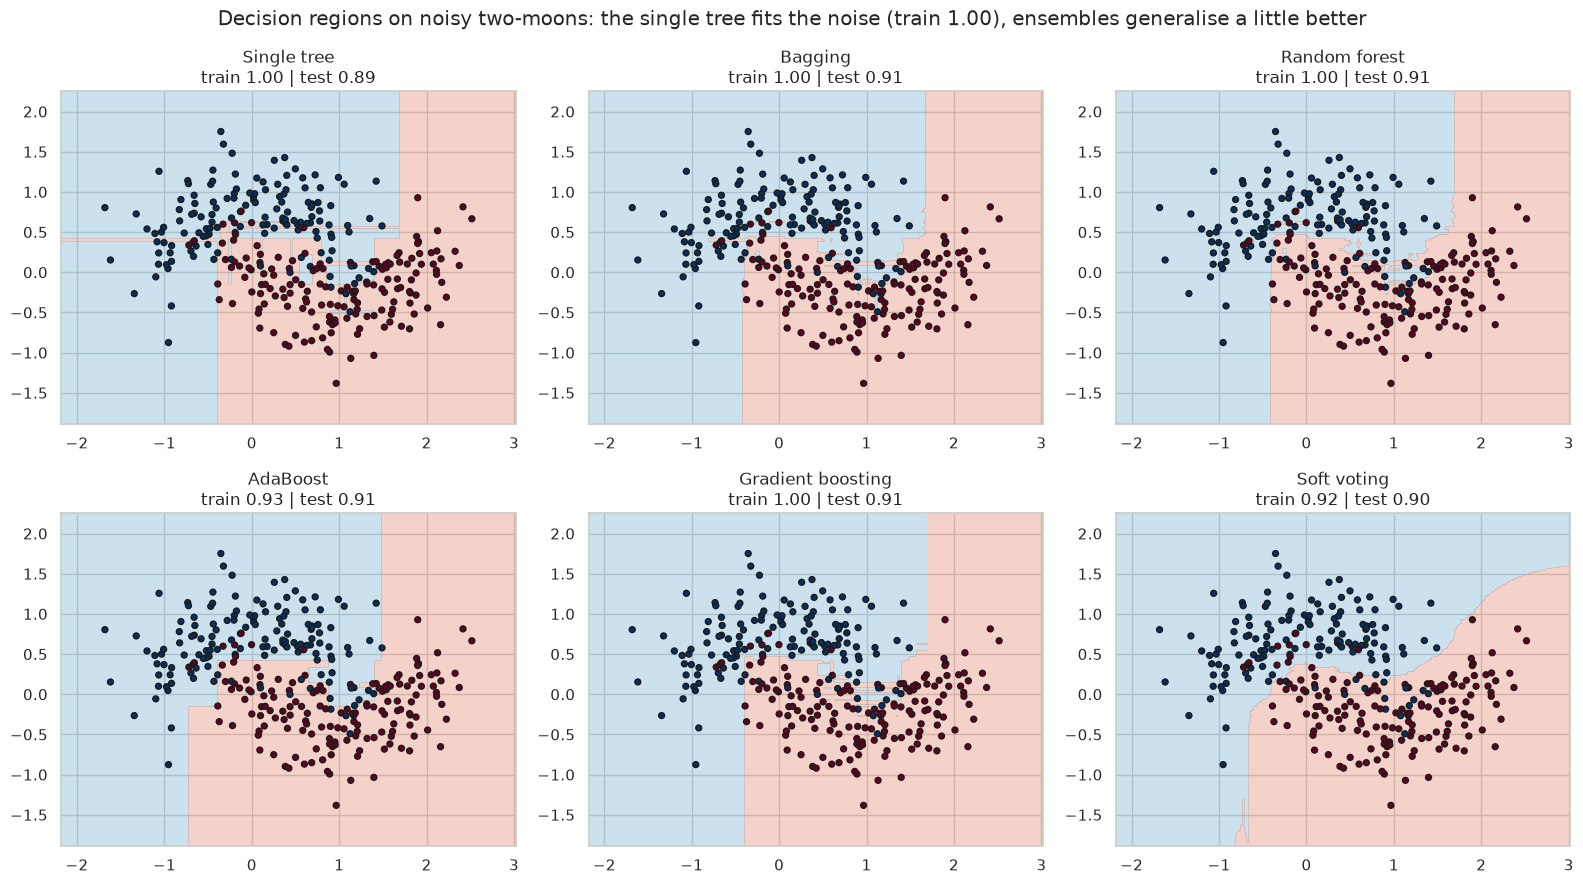

In [19]:
Xm, ym = make_moons(500, noise=0.3, random_state=3); Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.4, random_state=0)
show = {"Single tree": DecisionTreeClassifier(random_state=0), "Bagging": BaggingClassifier(DecisionTreeClassifier(), 100, random_state=0), "Random forest": RandomForestClassifier(200, random_state=0),
        "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=0), "Gradient boosting": GradientBoostingClassifier(random_state=0),
        "Soft voting": VotingClassifier([("lr", LogisticRegression()), ("svm", make_pipeline(StandardScaler(), CalibratedClassifierCV(SVC(), cv=5))), ("rf", RandomForestClassifier(100, random_state=0))], voting="soft")}
fig, ax = plt.subplots(2, 3, figsize=(16, 9))
for a_, (k, m) in zip(ax.ravel(), show.items()):
    m.fit(Xm_tr, ym_tr); boundary(a_, m, Xm_tr, ym_tr, f"{k}\ntrain {m.score(Xm_tr, ym_tr):.2f} | test {m.score(Xm_te, ym_te):.2f}")
plt.suptitle("Decision regions on noisy two-moons: the single tree fits the noise (train 1.00), ensembles generalise a little better"); plt.tight_layout(); plt.show()

### Step 5 – Ensembles for *unsupervised* learning: consensus clustering
A single K-means run depends on its random initialisation (and the chosen $k$), so quality varies from run to run. Combine many clusterings through a **co-association matrix**
$C_{ij}$ = fraction of runs that put samples $i,j$ in the same cluster, then cluster the distance $1-C$ hierarchically (average linkage).
Members here are K-means runs on the digits data (20 PCA components) using random subsets of components, a random number of clusters ($k\in[8,14]$) and random seeds.
The consensus is a *stable* answer — typically at least as good as an average single run, without the lottery of one initialisation (it need not beat the luckiest run).

ARI vs true digits:  consensus of 60 runs = 0.734   |   single K-means runs: mean 0.656, min 0.578, max 0.739


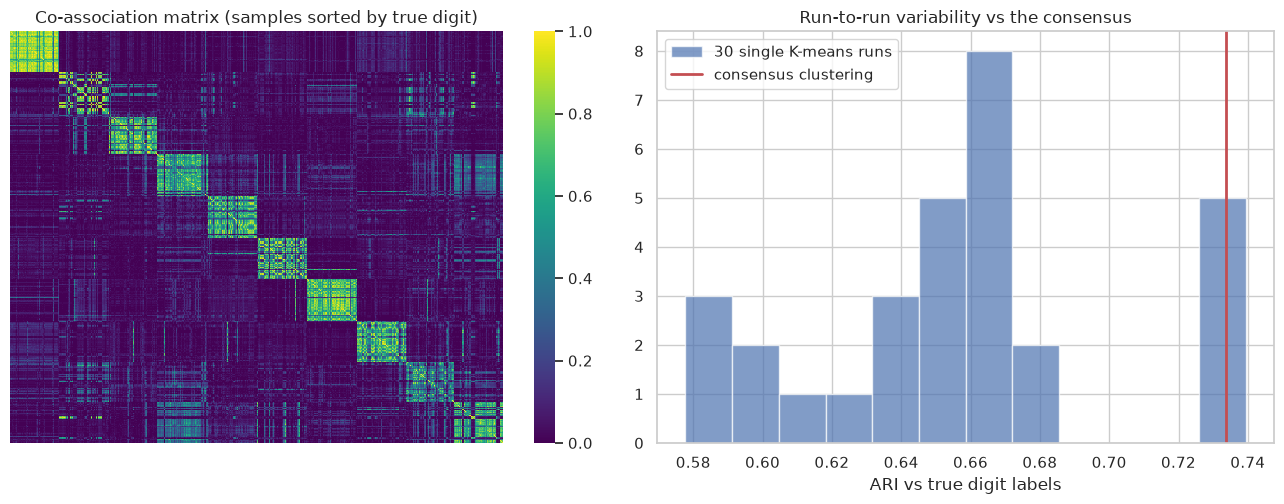

In [20]:
from scipy.spatial.distance import squareform
digits = load_digits(); Xdg = PCA(20, random_state=0).fit_transform(digits.data); ydg = digits.target

single = [adjusted_rand_score(ydg, KMeans(10, n_init=1, random_state=s).fit_predict(Xdg)) for s in range(30)]      # 30 plain K-means runs, k = 10
rng = np.random.default_rng(0); R = 60; C = np.zeros((len(Xdg), len(Xdg)))
for r in range(R):
    feats = rng.choice(20, size=int(rng.integers(8, 20)), replace=False); k = int(rng.integers(8, 15))
    lab = KMeans(k, n_init=1, random_state=int(rng.integers(1 << 30))).fit_predict(Xdg[:, feats]); C += (lab[:, None] == lab[None])
C /= R
cons = fcluster(linkage(squareform(1 - C, checks=False), "average"), 10, "maxclust") - 1
ari_cons = adjusted_rand_score(ydg, cons)
print(f"ARI vs true digits:  consensus of {R} runs = {ari_cons:.3f}   |   single K-means runs: mean {np.mean(single):.3f}, min {np.min(single):.3f}, max {np.max(single):.3f}")

order = np.argsort(ydg, kind="stable")
fig, ax = plt.subplots(1, 2, figsize=(13, 5.2))
sns.heatmap(C[np.ix_(order, order)], cmap="viridis", ax=ax[0], xticklabels=False, yticklabels=False); ax[0].set_title("Co-association matrix (samples sorted by true digit)")
ax[1].hist(single, bins=12, alpha=.7, label="30 single K-means runs"); ax[1].axvline(ari_cons, c="r", lw=2, label="consensus clustering"); ax[1].set(xlabel="ARI vs true digit labels", title="Run-to-run variability vs the consensus"); ax[1].legend()
plt.tight_layout(); plt.show()

## Summary
* **BMA** weights models by their evidence and concentrates on the best one as data grow; **bagging** reduces variance by averaging bootstrap-trained models; **boosting** (AdaBoost, gradient boosting) reduces bias by adding learners sequentially — both implemented from scratch.
* **GAMs** keep additive interpretability while learning non-linear shape functions.
* **CART** implemented from scratch (Gini/entropy, best-split search, pruning); identical predictions to scikit-learn; single trees are unstable and over-fit.
* **Ensembles** (bagging, random forest, extra-trees, AdaBoost, gradient boosting, voting, stacking) compared with cross-validation, ROC, OOB error and importance measures; a consensus-clustering ensemble for the unsupervised case.